In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation

col_TBW_calc_4C = 'Gold_Standard_TBW'

In [2]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.titlesize': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 12,

    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',

    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True
})

In [3]:
def format_plot(ax, title, xlabel, ylabel, horizontal=False):

    ax.set_title(title, pad=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if horizontal:
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.grid(axis='y', visible=False)
    else:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.grid(axis='x', visible=False)

In [4]:
filePath = '../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)

In [5]:
def get_clean_mask(data, threshold=3.5):
    """
    Apply Iglewicz and Hoaglin's robust outlier detection.
    Returns: Boolean mask (True = Valid, False = Outlier)
    """
    median = np.median(data)
    mad = median_abs_deviation(data, scale='normal')
    modified_z_score = 0.6745 * (data - median) / mad
    return modified_z_score.abs() < threshold

def get_symmetric_limits(data):
    """
    Calculates a SYMMETRIC limit centered on 0.
    1. Takes the Absolute Value of the errors.
    2. Finds the Nth percentile of those absolute values.
    3. Returns [-Limit, +Limit].
    """
    abs_data = data.abs()
    limit = np.percentile(abs_data, 99)
    return -limit, limit

In [6]:
df_bioimpedance = df[[
    'Weight',
    'Total Body Water (TBW)',         # Measured in kg
    'Extracellular Water (ECW)',      # Measured in kg
    'Intracellular Water (ICW)',      # Measured in kg
    'Extracellular Fluid/Total Body Water (ECF/TBW)', # Derived Fluid Ratio
    'Total Body Fat Ratio (TBFR) (%)',# Percentage of total mass
    'Lean Mass (LM) (%)',             # Percentage of fat-free mass
    'Body Protein Content (Protein) (%)', # Protein composition percentage
    'Visceral Fat Rating (VFR)',      # Corresponds to "Visceral Adiposity Index" in text [cite: 61]
    'Bone Mass (BM)',                 # Measured in kg
    'Muscle Mass (MM)',               # Measured in kg
    'Obesity (%)',                    # Degree of obesity percentage
    'Total Fat Content (TFC)',        # Measured in kg
    'Visceral Fat Area (VFA)',        # Measured in kg
    'Visceral Muscle Area (VMA) (Kg)' # Measured in kg
]].copy()

df_bioimpedance

,Weight,Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg)
0,92.8,52.9,21.2,31.7,40.00,19.20,80.84,18.88,9,3.7,71.4,23.40,17.8,10.60,39.7
1,94.5,43.1,19.5,23.6,45.00,32.80,67.20,16.68,15,3.2,60.3,38.80,31.0,18.40,32.7
2,91.1,47.2,20.1,27.1,43.00,27.30,72.67,16.35,15,3.3,62.9,41.70,24.9,16.20,34.0
3,67.7,41.4,17.0,24.4,41.00,15.80,84.19,16.90,6,2.9,54.1,9.00,10.7,6.50,29.2
4,89.6,51.4,20.0,31.4,39.00,20.00,80.02,16.81,8,3.5,68.2,28.60,17.9,10.40,37.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,88.8,47.6,20.0,28.0,42.01,24.66,75.23,16.13,11,3.3,63.5,14.39,21.9,13.58,34.2
315,53.4,29.3,12.3,17.0,42.00,23.60,76.40,15.96,2,2.1,38.7,1.50,12.6,5.10,22.2
316,96.6,49.2,21.0,28.2,43.00,28.80,71.22,15.87,16,3.4,65.4,48.40,27.8,17.10,35.6
317,88.4,50.2,19.9,30.3,40.00,21.10,78.85,16.30,8,3.4,66.3,28.30,18.7,11.00,36.1


In [7]:
# Track A: Physics (Summation) | TBW - (ECW + ICW)
col_TBW_calc_sum = 'TBW_calc_sum'
df_bioimpedance[col_TBW_calc_sum] = df_bioimpedance['Extracellular Water (ECW)'] + df_bioimpedance['Intracellular Water (ICW)']
col_TBW_disc_sum = 'TBW_disc_sum'
df_bioimpedance[col_TBW_disc_sum] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_sum]

# Track B: Logic (Ratio) | TBW - ECW / (Ratio/100)
col_TBW_calc_ratio = 'TBW_calc_ratio'
df_bioimpedance[col_TBW_calc_ratio] = df_bioimpedance['Extracellular Water (ECW)'] / (df_bioimpedance['Extracellular Fluid/Total Body Water (ECF/TBW)'] / 100)
col_TBW_disc_ratio = 'TBW_disc_ratio'
df_bioimpedance[col_TBW_disc_ratio] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_ratio]

# Track C: 4-Component Model | TBW - (Weight - Fat - Bone - Protein - 0.013*Weight)
epsilon_4C = df_bioimpedance['Weight']*0.013
col_TFC_calc_ratio = 'TFC_calc_ratio'
df_bioimpedance[col_TFC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Total Body Fat Ratio (TBFR) (%)'] / 100))

col_TPC_calc_ratio = 'TPC_calc_ratio'
df_bioimpedance[col_TPC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Body Protein Content (Protein) (%)'] / 100))

col_TBW_calc_4C = 'TBW_calc_4C'
df_bioimpedance[col_TBW_calc_4C] = df_bioimpedance['Weight'] - df_bioimpedance[col_TFC_calc_ratio] - df_bioimpedance['Bone Mass (BM)'] - df_bioimpedance[
    col_TPC_calc_ratio] - epsilon_4C
col_TBW_disc_4C = 'TBW_disc_4C'
df_bioimpedance[col_TBW_disc_4C] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_4C]

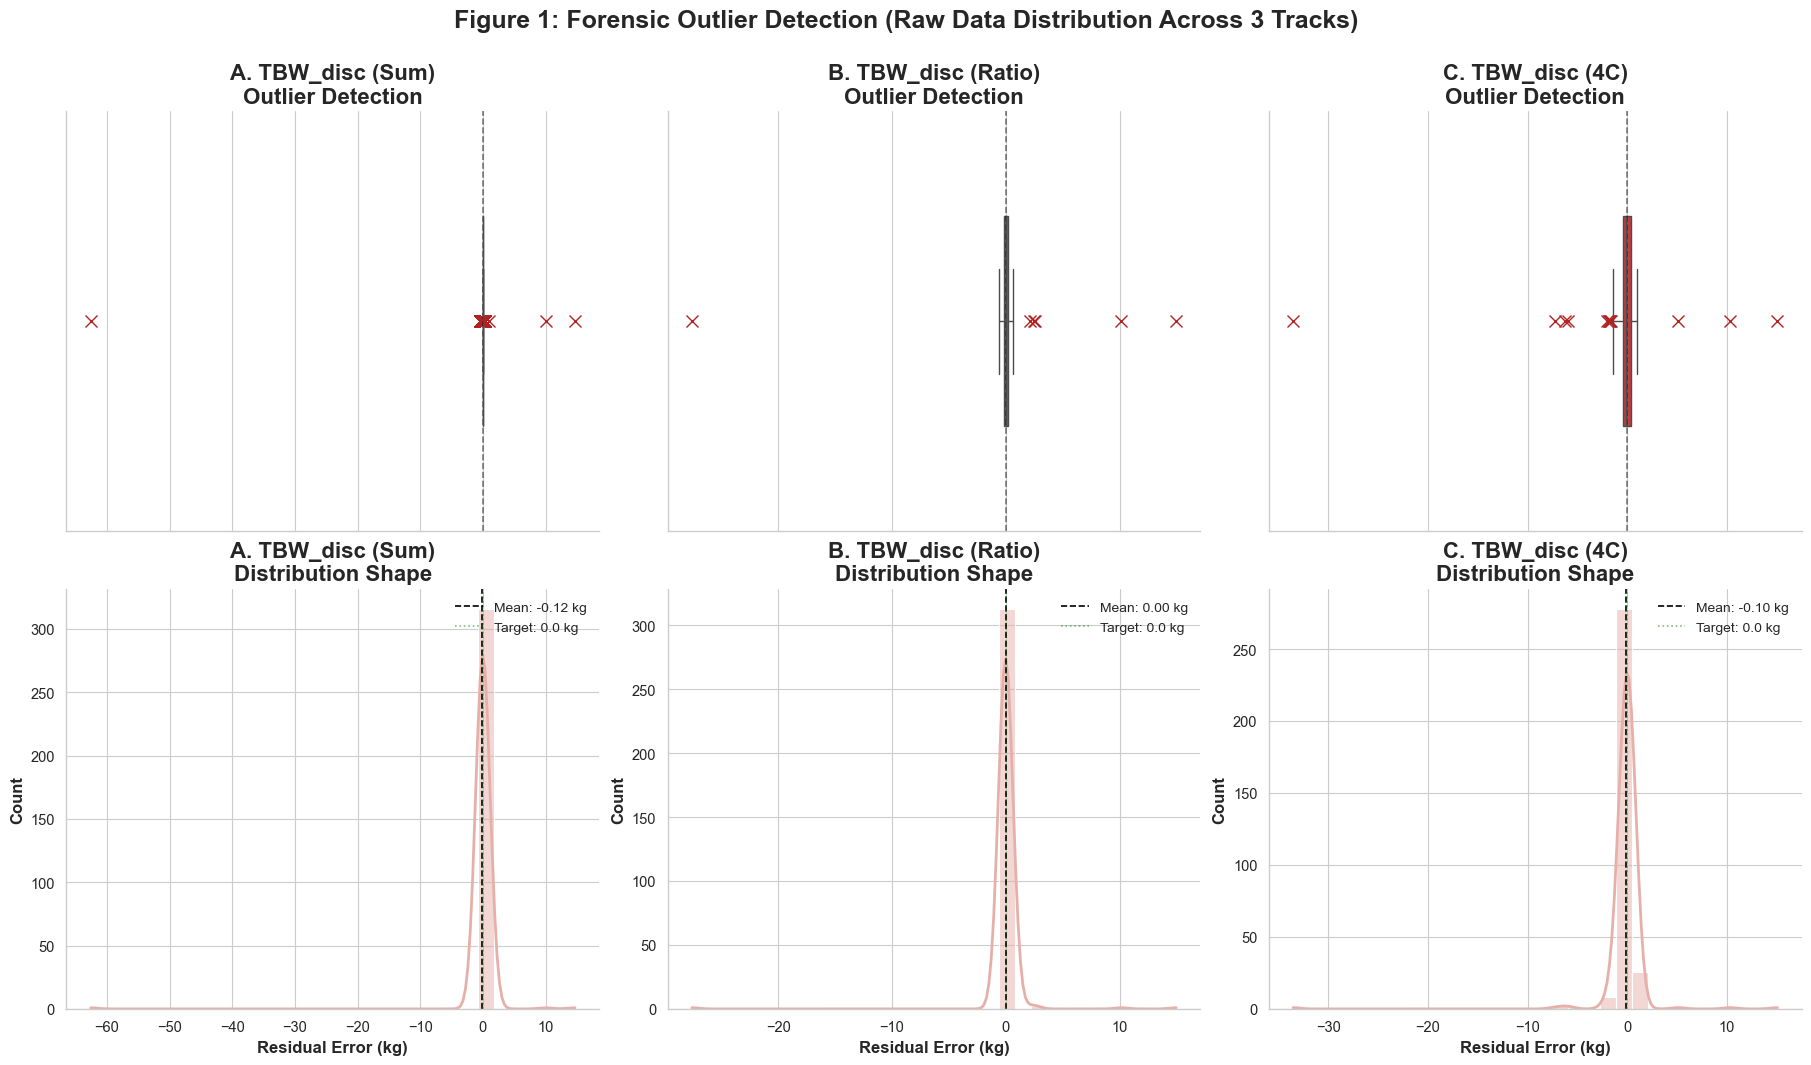

In [8]:
#(Figure 1: Distribution Analysis) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True, sharex='col')

tracks = [
    ('A. TBW_disc (Sum)'    , col_TBW_disc_sum),
    ('B. TBW_disc (Ratio)'  , col_TBW_disc_ratio),
    ('C. TBW_disc (4C)'     , col_TBW_disc_4C)
]

for i, (title, col) in enumerate(tracks):
    data = df_bioimpedance[col]

    # Upper Plot: Boxplot
    sns.boxplot(x=data, ax=axes[0, i], color='tab:red', width=0.5,
                flierprops={"marker": "x", "markeredgecolor": "firebrick", "markersize": 8})
    axes[0, i].set_title(f"{title}\nOutlier Detection", fontweight='bold')
    axes[0, i].axvline(0, color='black', linestyle='--', alpha=0.5)

    # Lower Plot: Histogram
    # Safety Check: Prevent crash on empty columns
    if not data.isnull().all():
        sns.histplot(x=data, ax=axes[1, i], color='#E6B0AA', bins=30, kde=True,
                     line_kws={'linewidth': 2, 'color': 'firebrick'})

        mean_val = data.mean()
        axes[1, i].axvline(mean_val, color='black', linestyle='--', label=f'Mean: {mean_val:.2f} kg')
        axes[1, i].axvline(0, color='green', linestyle=':', alpha=0.5, label='Target: 0.0 kg')

    axes[1, i].set_title(f"{title}\nDistribution Shape", fontweight='bold')
    axes[1, i].set_xlabel("Residual Error (kg)")
    axes[1, i].legend(loc='upper right', fontsize=10)

plt.suptitle("Figure 1: Forensic Outlier Detection (Raw Data Distribution Across 3 Tracks)",
             y=1.05, fontsize=18, fontweight='bold')
plt.show()

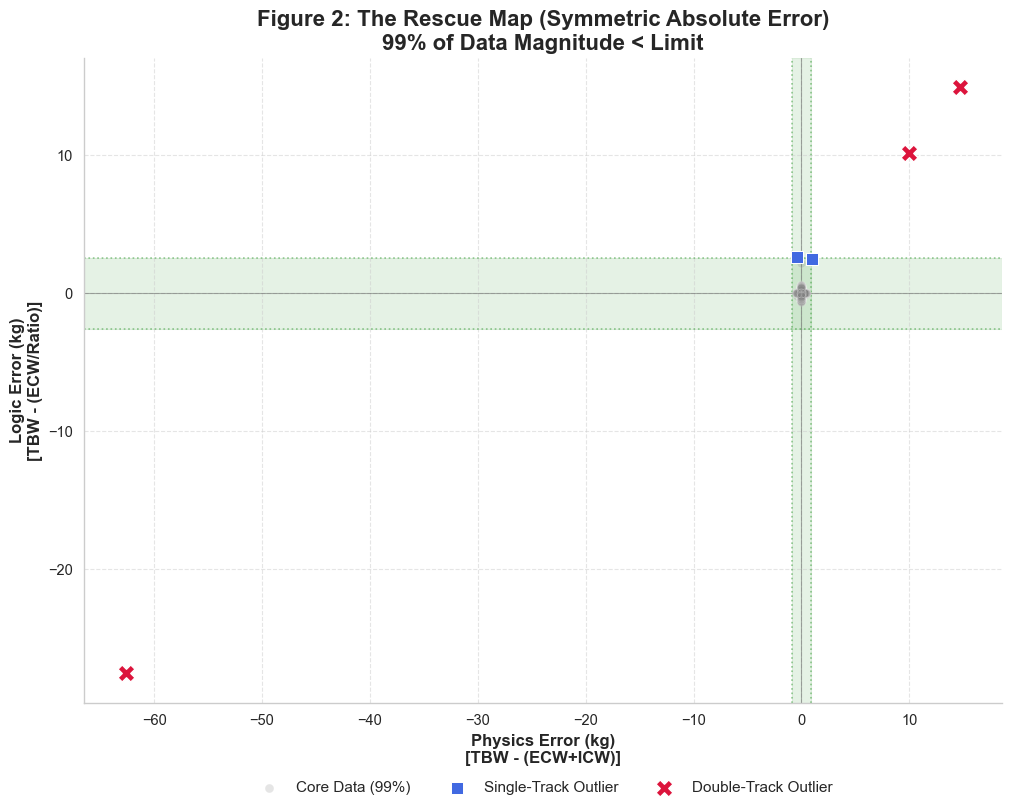

In [9]:
# --- 2. Figure 2: The Rescue Map (Symmetric Absolute Percentiles) ---
# 1. CALCULATE LIMITS (Symmetric)
x_lim_min, x_lim_max = get_symmetric_limits(df_bioimpedance[col_TBW_disc_sum])
y_lim_min, y_lim_max = get_symmetric_limits(df_bioimpedance[col_TBW_disc_ratio])

# 2. GENERATE MASKS (Using the new symmetric limits)
mask_good = (df_bioimpedance[col_TBW_disc_sum].between(x_lim_min, x_lim_max)) & \
            (df_bioimpedance[col_TBW_disc_ratio].between(y_lim_min, y_lim_max))

mask_outer = (~df_bioimpedance[col_TBW_disc_sum].between(x_lim_min, x_lim_max)) & \
             (~df_bioimpedance[col_TBW_disc_ratio].between(y_lim_min, y_lim_max))

mask_axis = ~(mask_good | mask_outer)

# --- PLOTTING ---
fig2, ax2 = plt.subplots(figsize=(10, 8), constrained_layout=True)

# A. DRAW THE ZONES (Perfectly Centered Cross)
ax2.axvspan(x_lim_min, x_lim_max, color='green', alpha=0.1, zorder=0)
ax2.axhspan(y_lim_min, y_lim_max, color='green', alpha=0.1, zorder=0)

# Dotted boundaries for visibility
ax2.axvline(x_lim_min, color='green', linestyle=':', alpha=0.4)
ax2.axvline(x_lim_max, color='green', linestyle=':', alpha=0.4)
ax2.axhline(y_lim_min, color='green', linestyle=':', alpha=0.4)
ax2.axhline(y_lim_max, color='green', linestyle=':', alpha=0.4)

# Center lines
ax2.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3, zorder=1)
ax2.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3, zorder=1)

# B. SCATTER PLOTS
sns.scatterplot(data=df_bioimpedance[mask_good], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='gray', alpha=0.2, s=40, label=f'Core Data (99%)', ax=ax2, zorder=2)

sns.scatterplot(data=df_bioimpedance[mask_axis], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='royalblue', s=80, marker='s', label='Single-Track Outlier', ax=ax2, zorder=3)

sns.scatterplot(data=df_bioimpedance[mask_outer], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='crimson', s=150, marker='X', label='Double-Track Outlier', ax=ax2, zorder=4)

ax2.set_title(f"Figure 2: The Rescue Map (Symmetric Absolute Error)\n99% of Data Magnitude < Limit",
              fontweight='bold', fontsize=16)
ax2.set_xlabel("Physics Error (kg)\n[TBW - (ECW+ICW)]", fontweight='bold')
ax2.set_ylabel("Logic Error (kg)\n[TBW - (ECW/Ratio)]", fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5, zorder=0)

ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
           ncol=3, frameon=False, fontsize=11)

plt.show()

In [10]:
# 2.3 Dynamic Thresholding
limit_physics = get_symmetric_limits(df_bioimpedance[col_TBW_disc_sum])[1]
limit_logic   = get_symmetric_limits(df_bioimpedance[col_TBW_disc_ratio])[1]

# 2.4 Repair Logic
mask_physics_fail = df_bioimpedance[col_TBW_disc_sum].abs() > limit_physics
mask_logic_fail   = df_bioimpedance[col_TBW_disc_ratio].abs() > limit_logic

mask_double       = mask_physics_fail & mask_logic_fail
mask_logic_only   = mask_logic_fail & (~mask_physics_fail)
mask_physics_only = mask_physics_fail & (~mask_logic_fail)

col_TBW_fixed = 'TBW_fixed'
df_bioimpedance[col_TBW_fixed] = df['Total Body Water (TBW)']
df_bioimpedance['Data Status'] = 'Valid Data (Unchanged)'
df_bioimpedance.loc[mask_double | mask_logic_only | mask_physics_only, 'Data Status'] = 'Repaired Data (Fixed)'

df_bioimpedance.loc[mask_double, col_TBW_fixed] = df_bioimpedance.loc[mask_double, col_TBW_calc_ratio]
df_bioimpedance.loc[mask_logic_only, col_TBW_fixed] = df_bioimpedance.loc[mask_logic_only, col_TBW_calc_sum]
df_bioimpedance.loc[mask_physics_only, col_TBW_fixed] = df_bioimpedance.loc[mask_physics_only, col_TBW_calc_ratio]

df_bioimpedance['Mean_Raw'] = (df_bioimpedance['Total Body Water (TBW)'] + df_bioimpedance[col_TBW_calc_4C]) / 2
df_bioimpedance['Diff_Raw'] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_4C]
df_bioimpedance['Mean_Final'] = (df_bioimpedance[col_TBW_fixed] + df_bioimpedance[col_TBW_calc_4C]) / 2
df_bioimpedance['Diff_Final'] = df_bioimpedance[col_TBW_fixed] - df_bioimpedance[col_TBW_calc_4C]

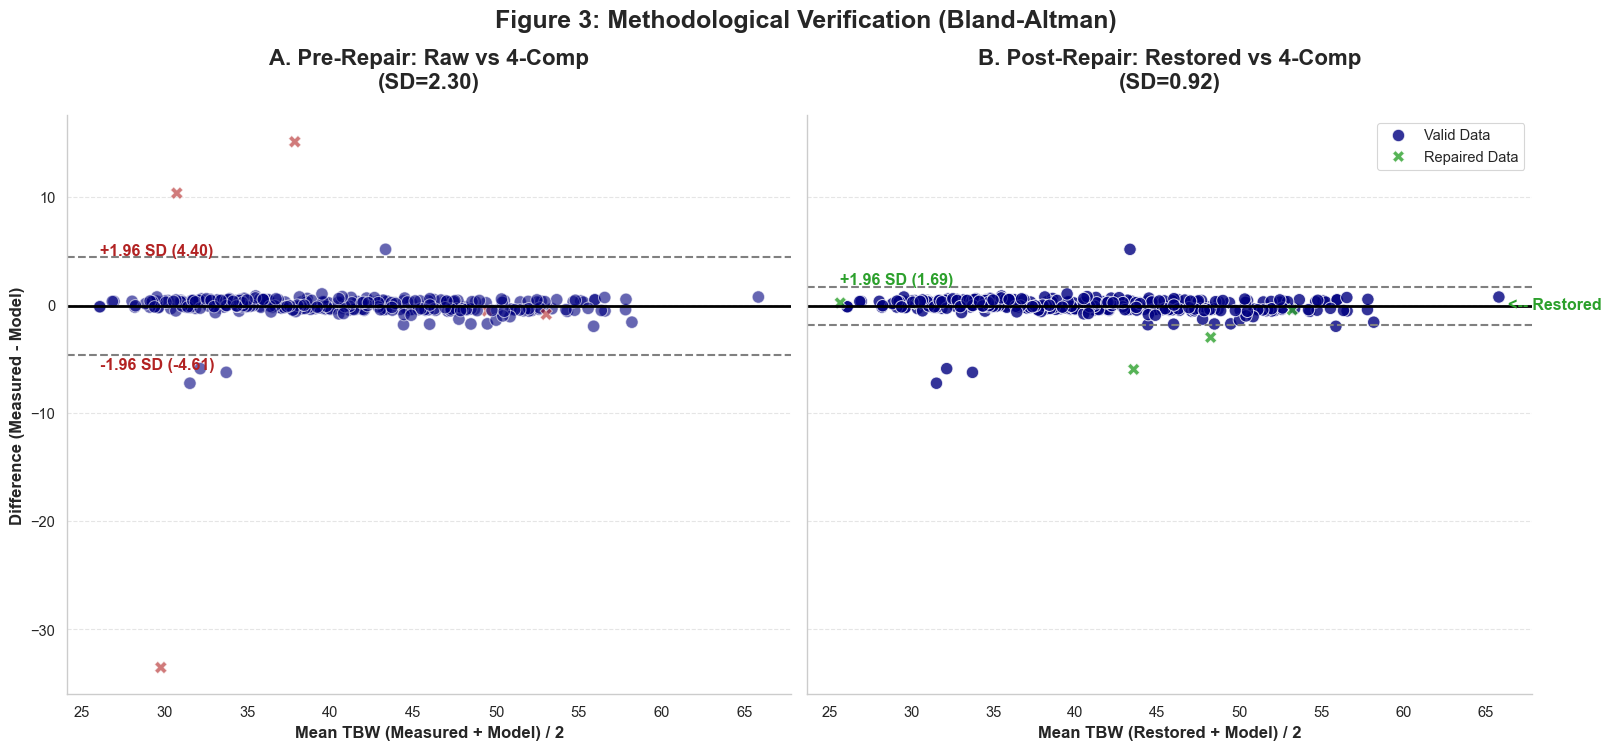

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True, constrained_layout=True)

# Colors
palette_raw = {'Valid Data (Unchanged)': 'navy', 'Repaired Data (Fixed)': 'firebrick'}
palette_fix = {'Valid Data (Unchanged)': 'navy', 'Repaired Data (Fixed)': 'tab:green'}
markers = {'Valid Data (Unchanged)': 'o', 'Repaired Data (Fixed)': 'X'}

# --- PLOT A ---
ax1 = axes[0]
# Replaced df with df_bioimpedance
sns.scatterplot(data=df_bioimpedance, x='Mean_Raw', y='Diff_Raw', hue='Data Status', style='Data Status',
                palette=palette_raw, markers=markers, s=80, alpha=0.6, ax=ax1, legend=False)

# Stats (Replaced df with df_bioimpedance)
mean_raw, sd_raw = df_bioimpedance['Diff_Raw'].mean(), df_bioimpedance['Diff_Raw'].std()
loa_upper, loa_lower = mean_raw + 1.96*sd_raw, mean_raw - 1.96*sd_raw

# Apply User Format
format_plot(ax1, f"A. Pre-Repair: Raw vs 4-Comp\n(SD={sd_raw:.2f})",
            "Mean TBW (Measured + Model) / 2", "Difference (Measured - Model)")

# Add Lines & Text
ax1.axhline(mean_raw, color='black', lw=2)
ax1.axhline(loa_upper, color='gray', ls='--', lw=1.5)
ax1.axhline(loa_lower, color='gray', ls='--', lw=1.5)
# Replaced df with df_bioimpedance for min() calls
ax1.text(df_bioimpedance['Mean_Raw'].min(), loa_upper + 0.2, f'+1.96 SD ({loa_upper:.2f})', color='firebrick', fontweight='bold')
ax1.text(df_bioimpedance['Mean_Raw'].min(), loa_lower - 0.2, f'-1.96 SD ({loa_lower:.2f})', color='firebrick', fontweight='bold', va='top')

# --- PLOT B ---
ax2 = axes[1]
# Replaced df with df_bioimpedance
sns.scatterplot(data=df_bioimpedance, x='Mean_Final', y='Diff_Final', hue='Data Status', style='Data Status',
                palette=palette_fix, markers=markers, s=80, alpha=0.8, ax=ax2)

# Stats (Replaced df with df_bioimpedance)
mean_fix, sd_fix = df_bioimpedance['Diff_Final'].mean(), df_bioimpedance['Diff_Final'].std()
loa_upper_fix, loa_lower_fix = mean_fix + 1.96*sd_fix, mean_fix - 1.96*sd_fix

# Apply User Format
format_plot(ax2, f"B. Post-Repair: Restored vs 4-Comp\n(SD={sd_fix:.2f})",
            "Mean TBW (Restored + Model) / 2", "")

# Add Lines & Text
ax2.axhline(mean_fix, color='black', lw=2)
ax2.axhline(loa_upper_fix, color='gray', ls='--', lw=1.5)
ax2.axhline(loa_lower_fix, color='gray', ls='--', lw=1.5)
# Replaced df with df_bioimpedance for min() and max() calls
ax2.text(df_bioimpedance['Mean_Final'].min(), loa_upper_fix + 0.2, f'+1.96 SD ({loa_upper_fix:.2f})', color='tab:green', fontweight='bold')
ax2.text(df_bioimpedance['Mean_Final'].max(), 0, "  <-- Restored", color='tab:green', va='center', fontweight='bold')

# Legend
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, ['Valid Data', 'Repaired Data'], loc='upper right', frameon=True)

plt.suptitle("Figure 3: Methodological Verification (Bland-Altman)", y=1.05, fontsize=18, fontweight='bold')
plt.show()